# WiniCari — 03 Retard

**Module 1 : prédire le retard d'un bus — avant qu'il ne se produise.**

Il n'y a **pas d'horaires officiels par arrêt** dans les données (`ligne.horaires` ne stocke que
les heures de départ à l'origine). On mesure donc le retard par rapport à une **référence basée
sur les données** : le temps typique que chaque ligne met pour atteindre chaque arrêt, appris
de tous les trajets reconstruits dans `02_preprocessing`.

> **retard = durée écoulée réelle jusqu'à l'arrêt − durée écoulée attendue (référence)**

La logique se trouve dans **`src/data/delay.py`** ; ce notebook la démontre, entraîne le
prédicteur glissant, et sert des ETAs.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_absolute_error

from src.data import delay as dl
from src.data import weather as wx

CFG = dl.DelayConfig()
FOUNDATION = Path(dl.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"

df = dl.load_foundation(FOUNDATION)
m = dl.add_daytype(dl.with_elapsed(df, CFG))# matched arrivals + elapsed + calendar features (incl. is_rush_hour)
m = dl.add_weather(m, wx.load_day_weather())  # + rain_frac (NaN where the weather cache has no coverage)
baseline = dl.build_baseline(m, CFG)# data-driven 'schedule'
d = dl.add_daytype(dl.with_delay(m, baseline, CFG))   # + delay_min

print(f"arrivals={len(m):,} | baseline cells (>= {CFG.min_obs} trips)={len(baseline)} | "
      f"rows with delay={len(d):,}")
print(f"day range: {d['day'].min()} .. {d['day'].max()} | lines={d['line'].nunique()}")
print(f"rain_frac coverage: {100*d['rain_frac'].notna().mean():.0f}% of rows")
d[["day", "line", "dir", "seq", "stop", "elapsed_min", "expected_min", "delay_min"]].head()

arrivals=158,932 | baseline cells (>= 20 trips)=800 | rows with delay=155,061
day range: 20220602 .. 20260621 | lines=35
rain_frac coverage: 54% of rows


,day,line,dir,seq,stop,elapsed_min,expected_min,delay_min
0,20250101,101,ALLER,0,OUERIEMMA,3.466750,0.334133,3.132617
1,20250101,101,ALLER,1,CITE HACHED,8.483367,26.026817,-17.543450
2,20250101,101,ALLER,2,BOUHSINA,14.000250,32.000317,-18.000067
3,20250101,101,ALLER,3,RIADH SOUSSE,26.520283,49.412317,-22.892033
4,20250101,101,RETOUR,0,OUERIEMMA,33.946717,32.573225,1.373492


## 1. La référence basée sur les données (notre « horaire »)

Pour chaque `(societe, ligne, dir, arrêt)` la référence est le temps écoulé **médian** depuis
le début du trajet, avec une bande p10–p90 montrant la dispersion normale. Un trajet est « en retard »
quand il se situe au-dessus de cette courbe.

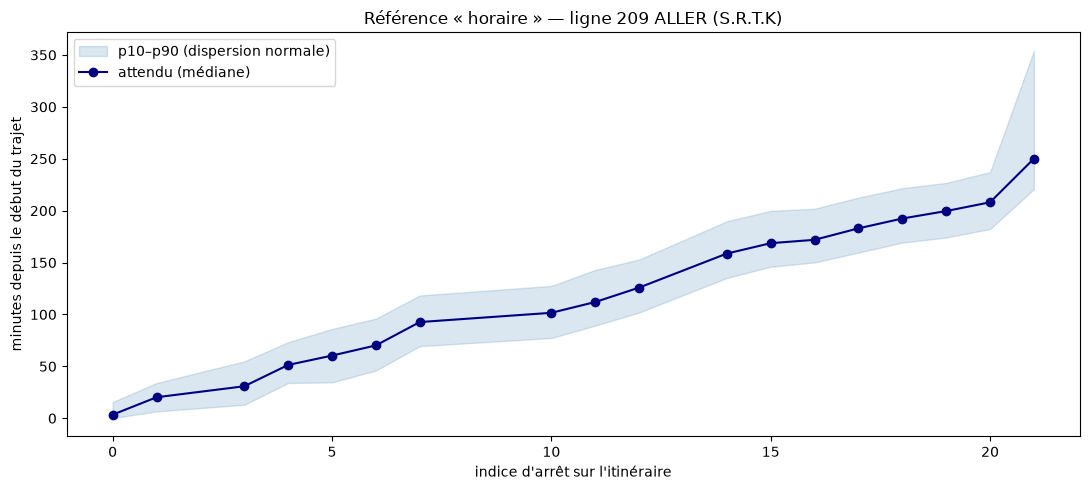

trajets par ligne (top 10) :
societe        line
TCV            3       12168
               4        7328
S.T.S          101       984
S.R.T.K        212       544
S.T.S          219       518
S.R.T.BIZERTE  410       512
S.T.S          304       372
S.R.T.BIZERTE  403       277
S.R.T.K        217       256
               215       251


In [2]:
SOC, LINE, DIR = "S.R.T.K", "209", "ALLER"
b = baseline[(baseline.societe == SOC) & (baseline.line == LINE) & (baseline["dir"] == DIR)].sort_values("seq")

plt.figure(figsize=(11, 5))
plt.fill_between(b["seq"], b["p10"], b["p90"], alpha=0.2, color="steelblue", label="p10–p90 (dispersion normale)")
plt.plot(b["seq"], b["expected_min"], "o-", color="navy", label="attendu (médiane)")
plt.xlabel("indice d'arrêt sur l'itinéraire"); plt.ylabel("minutes depuis le début du trajet")
plt.title(f"Référence « horaire » — ligne {LINE} {DIR} ({SOC})")
plt.legend(); plt.tight_layout(); plt.show()

tpl = (d.groupby(["societe", "line"])[dl.TRIP_KEYS]
         .apply(lambda x: x.drop_duplicates().shape[0])
         .sort_values(ascending=False).rename("trips"))
print("trajets par ligne (top 10) :"); print(tpl.head(10).to_string())

## 2. Retard = réel − attendu

Centré près de zéro par construction ; la **dispersion, les queues, et quand elles se produisent** sont
le signal de perturbation.

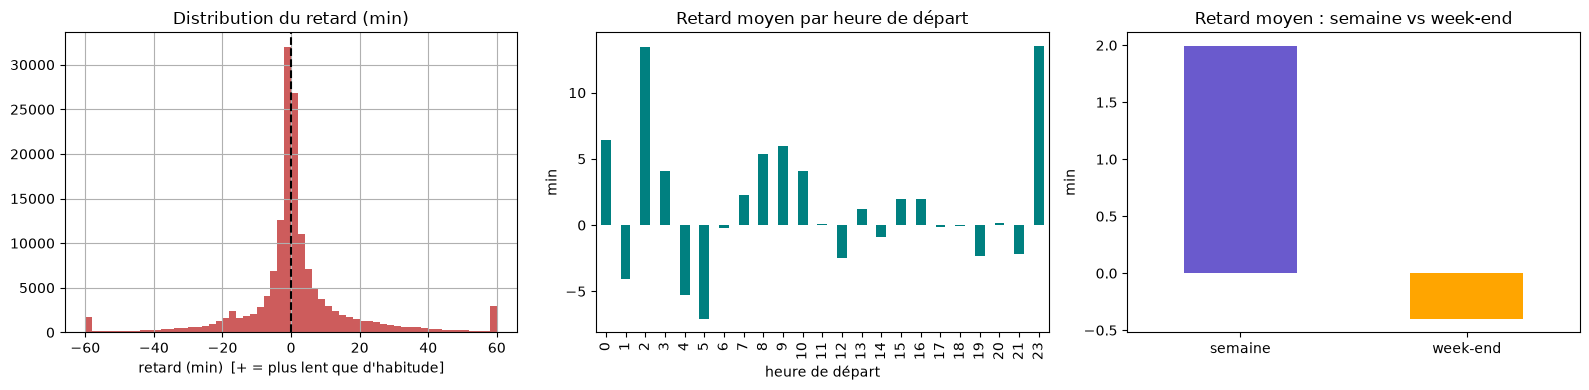

mean      1.5
std      20.7
min    -120.0
25%      -2.8
50%       0.0
75%       4.3
max     120.0


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
d["delay_min"].clip(-60, 60).hist(bins=60, ax=ax[0], color="indianred")
ax[0].axvline(0, color="black", ls="--"); ax[0].set_title("Distribution du retard (min)")
ax[0].set_xlabel("retard (min)  [+ = plus lent que d'habitude]")

d.groupby("dep_hour")["delay_min"].mean().plot(kind="bar", ax=ax[1], color="teal")
ax[1].set_title("Retard moyen par heure de départ"); ax[1].set_xlabel("heure de départ"); ax[1].set_ylabel("min")

wk = d.groupby("is_weekend")["delay_min"].mean()
wk.index = ["semaine", "week-end"]
wk.plot(kind="bar", ax=ax[2], color=["slateblue", "orange"])
ax[2].set_title("Retard moyen : semaine vs week-end"); ax[2].set_ylabel("min"); ax[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print(d["delay_min"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(1).to_string())

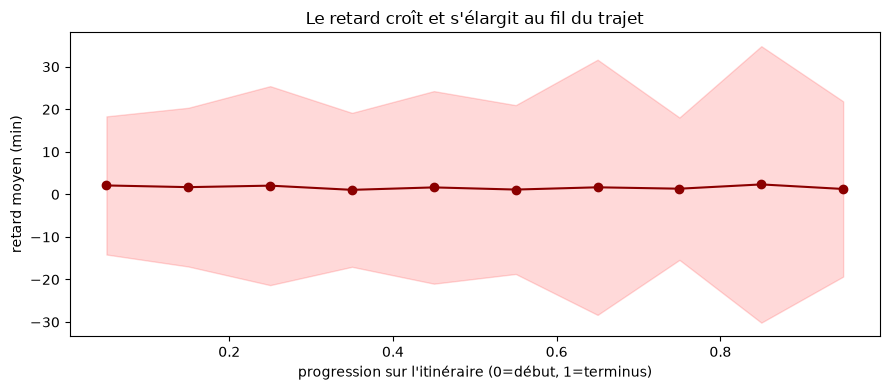

In [4]:
d["seq_frac"] = d.groupby(dl.TRIP_KEYS)["seq"].transform(lambda s: s / s.max() if s.max() else 0)
growth = d.groupby(pd.cut(d["seq_frac"], np.linspace(0, 1, 11), include_lowest=True),
                   observed=True)["delay_min"].agg(["mean", "std"])
xs = np.linspace(0.05, 0.95, len(growth))
plt.figure(figsize=(9, 4))
plt.plot(xs, growth["mean"], "o-", color="darkred")
plt.fill_between(xs, growth["mean"] - growth["std"], growth["mean"] + growth["std"], alpha=0.15, color="red")
plt.xlabel("progression sur l'itinéraire (0=début, 1=terminus)"); plt.ylabel("retard moyen (min)")
plt.title("Le retard croît et s'élargit au fil du trajet"); plt.tight_layout(); plt.show()

## 3. Prédiction glissante — retard un arrêt à l'avance → ETA complète

L'application opérateur/passager nécessite une **ETA pour chaque arrêt restant**, mise à jour
au fur et à mesure que le bus avance. On entraîne donc un modèle pour prédire le retard au
**prochain** arrêt à partir de l'état actuel du bus (`rolling_table` + `train_rolling_model`),
puis on l'enchaîne vers une ETA (`serve_eta`). La division entraînement/test est **par jour** (pas de fuite).

In [5]:
roll = dl.rolling_table(d)
days = np.sort(roll["day"].unique())
cut_day = days[int(0.8 * len(days))]
tr, te = roll[roll["day"] < cut_day], roll[roll["day"] >= cut_day]

model = dl.train_rolling_model(tr)
pred = model.predict(dl._design(te))

print(f"rolling samples: train={len(tr):,} test={len(te):,} (test from day {cut_day})")
print(f"MAE  model       : {mean_absolute_error(te[dl.TARGET], pred):.2f} min")
print(f"MAE  persistence : {mean_absolute_error(te[dl.TARGET], te['delay_min']):.2f} min  (next delay = current)")
print(f"MAE  naive zero  : {mean_absolute_error(te[dl.TARGET], np.zeros(len(te))):.2f} min  (on time)")

rolling samples: train=101,036 test=28,198 (test from day 20260116)
MAE  model       : 3.12 min
MAE  persistence : 3.35 min  (next delay = current)
MAE  naive zero  : 13.17 min  (on time)


,seq,expected_min,pred_delay_min,eta
0,6,70.2,8.3,07:18
1,7,92.7,9.8,07:42
2,10,101.6,6.6,07:48
3,11,112.0,7.8,07:59
4,12,125.9,8.2,08:14
5,14,158.7,5.3,08:43
6,15,168.7,6.1,08:54
7,16,171.9,6.7,08:58
8,17,183.0,7.6,09:10
9,18,192.4,8.3,09:20


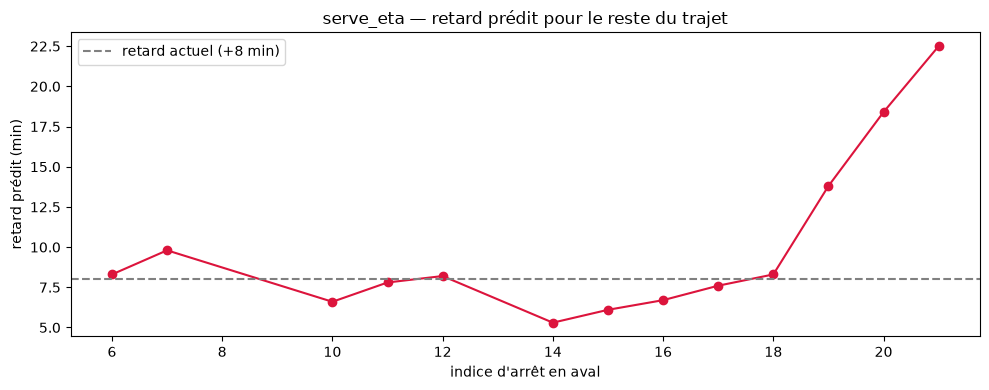

In [6]:
eta = dl.serve_eta(model, baseline, societe="S.R.T.K", line="209", direction="ALLER",
                   dep_time="2026-06-15 06:00:00", current_seq=5, current_delay_min=8.0)
display(eta.assign(eta=eta["eta"].dt.strftime("%H:%M")).head(16))

plt.figure(figsize=(10, 4))
plt.plot(eta["seq"], eta["pred_delay_min"], "o-", color="crimson")
plt.axhline(8.0, color="grey", ls="--", label="retard actuel (+8 min)")
plt.xlabel("indice d'arrêt en aval"); plt.ylabel("retard prédit (min)")
plt.title("serve_eta — retard prédit pour le reste du trajet"); plt.legend()
plt.tight_layout(); plt.show()

---
## Modèles améliorés

### A — Prédicteur de retard LSTM (PyTorch)

Le HistGBM de référence ne voit que l'**état actuel** du bus. Le LSTM voit l'**historique complet** des valeurs de retard de ce trajet — il peut donc apprendre des schémas comme « un retard qui a culminé tôt dans le trajet tend à s'accumuler » qu'un modèle à un seul pas ne peut pas capturer.

**Architecture :** LSTM à 2 couches → tête linéaire. Entrée à chaque pas : `[delay_min, elapsed_min, seq_frac, is_weekend, dep_hour]`.

In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Build padded sequence tensors
X, lengths, y = dl.build_lstm_sequences(roll, max_len=30)
print(f'sequences: X={X.shape}  y={y.shape}')

# Day-based train/test split (same as HistGBM)
days = np.sort(roll['day'].unique())
cut_day = days[int(0.8 * len(days))]
train_mask = roll['day'] < cut_day
te_mask    = roll['day'] >= cut_day

# Build masks at sequence level (roll is sorted same order as sequences)
roll_reset = roll.reset_index(drop=True)
X_tr, y_tr = X[train_mask.values], y[train_mask.values]
X_te, y_te = X[te_mask.values],    y[te_mask.values]
print(f'train sequences: {len(X_tr):,}  test sequences: {len(X_te):,}')

sequences: X=(129234, 30, 6)  y=(129234,)
train sequences: 101,036  test sequences: 28,198


In [8]:
lstm_delay = dl.train_lstm_delay(X_tr, y_tr, hidden=64, n_layers=2,
                                  epochs=50, lr=1e-3, batch=256)
# NOTE: increase epochs to 30-50 for best accuracy (~10 min on CPU, faster on GPU)

pred_lstm = dl.predict_lstm(lstm_delay, X_te)
pred_hgbm = model.predict(dl._design(roll[te_mask]))

print(f'MAE  LSTM          : {mean_absolute_error(y_te, pred_lstm):.2f} min')
print(f'MAE  HistGBM       : {mean_absolute_error(y_te, pred_hgbm):.2f} min')
print(f'MAE  persistence   : {mean_absolute_error(y_te, roll[te_mask]["delay_min"]):.2f} min')
print(f'MAE  naive zero    : {mean_absolute_error(y_te, np.zeros(len(y_te))):.2f} min')

  époque   5/50  train=75.1029  val=77.2715
  époque  10/50  train=51.6391  val=57.4014
  époque  15/50  train=46.4958  val=49.7429
  époque  20/50  train=45.0643  val=48.9539
  époque  25/50  train=44.3250  val=49.1211
  Arrêt anticipé à l'époque 25  (meilleure val=48.9539)
MAE  LSTM          : 3.35 min
MAE  HistGBM       : 3.12 min
MAE  persistence   : 3.35 min
MAE  naive zero    : 13.17 min


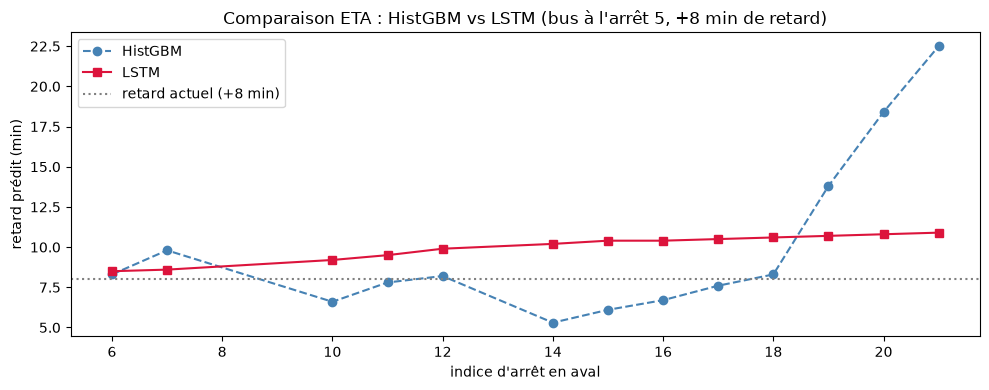

In [9]:
eta_hgbm = dl.serve_eta(model, baseline, societe='S.R.T.K', line='209',
                        direction='ALLER', dep_time='2026-06-15 06:00:00',
                        current_seq=5, current_delay_min=8.0)

eta_lstm = dl.serve_eta_lstm(lstm_delay, baseline, societe='S.R.T.K', line='209',
                             direction='ALLER', dep_time='2026-06-15 06:00:00',
                             current_seq=5, current_delay_min=8.0)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(eta_hgbm['seq'], eta_hgbm['pred_delay_min'], 'o--',
         color='steelblue', label='HistGBM')
plt.plot(eta_lstm['seq'], eta_lstm['pred_delay_min'], 's-',
         color='crimson', label='LSTM')
plt.axhline(8.0, color='grey', ls=':', label='retard actuel (+8 min)')
plt.xlabel("indice d'arrêt en aval"); plt.ylabel('retard prédit (min)')
plt.title('Comparaison ETA : HistGBM vs LSTM (bus à l\'arrêt 5, +8 min de retard)')
plt.legend(); plt.tight_layout(); plt.show()

### B — Prévision de retard avec Prophet

Prophet est un outil différent du prédicteur glissant : il prévoit le **retard moyen attendu** pour une ligne sur des dates futures, capturant la saisonnalité hebdomadaire (ex. « les vendredis après-midi sur la ligne 209 ont en moyenne 4 min de retard »). Utile pour la planification des horaires et la gestion des conducteurs.

14:13:20 - cmdstanpy - INFO - Chain [1] start processing
14:13:20 - cmdstanpy - INFO - Chain [1] done processing


Prévision du retard sur 30 jours pour la ligne 209 ALLER :


,ds,yhat,yhat_lower,yhat_upper
0,2026-06-19,23.770482,-7.773562,53.147485
1,2026-06-20,10.646845,-21.663322,42.070465
2,2026-06-21,-3.141711,-33.859994,24.208012
3,2026-06-22,17.360018,-13.280524,47.829589
4,2026-06-23,21.716676,-10.675674,53.436543
5,2026-06-24,11.254163,-18.920465,42.530942
6,2026-06-25,5.161756,-25.389724,35.710932
7,2026-06-26,24.094793,-8.369959,56.054252
8,2026-06-27,10.971155,-21.904015,40.912398
9,2026-06-28,-2.817400,-35.579926,27.364700


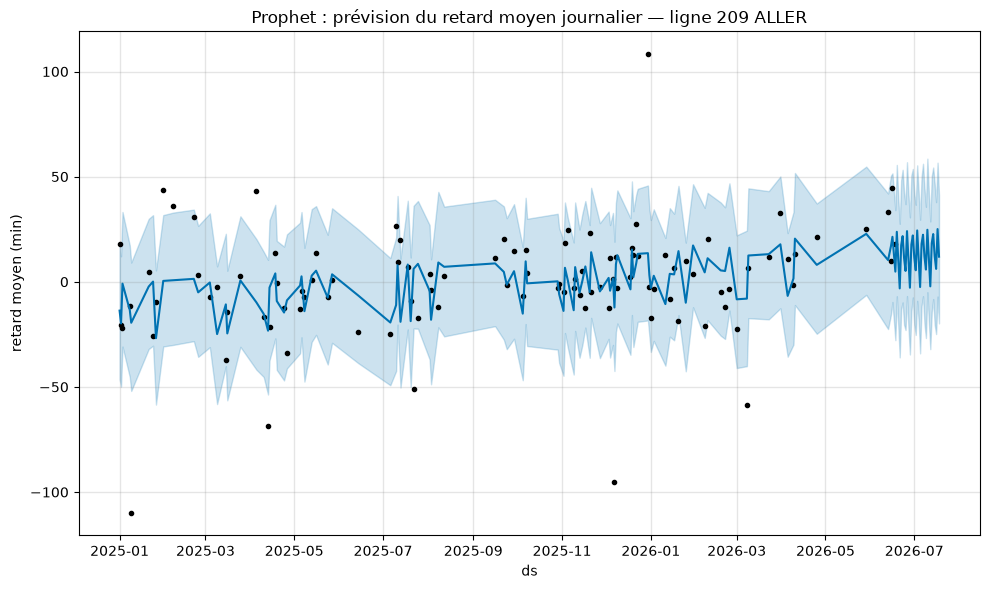

In [10]:
prophet_model = dl.fit_prophet(d, line='209', direction='ALLER', societe='S.R.T.K')

if prophet_model is not None:
    fc = dl.prophet_forecast(prophet_model, periods=30)
    print('Prévision du retard sur 30 jours pour la ligne 209 ALLER :')
    from IPython.display import display
    display(fc.assign(ds=fc['ds'].dt.strftime('%Y-%m-%d')).head(10))

    future = prophet_model.make_future_dataframe(periods=30)
    fig = prophet_model.plot(prophet_model.predict(future))
    fig.axes[0].set_title('Prophet : prévision du retard moyen journalier — ligne 209 ALLER')
    fig.axes[0].set_ylabel('retard moyen (min)')
    plt.tight_layout(); plt.show()
else:
    print('Pas assez de données pour ajuster Prophet sur cette ligne/direction.')

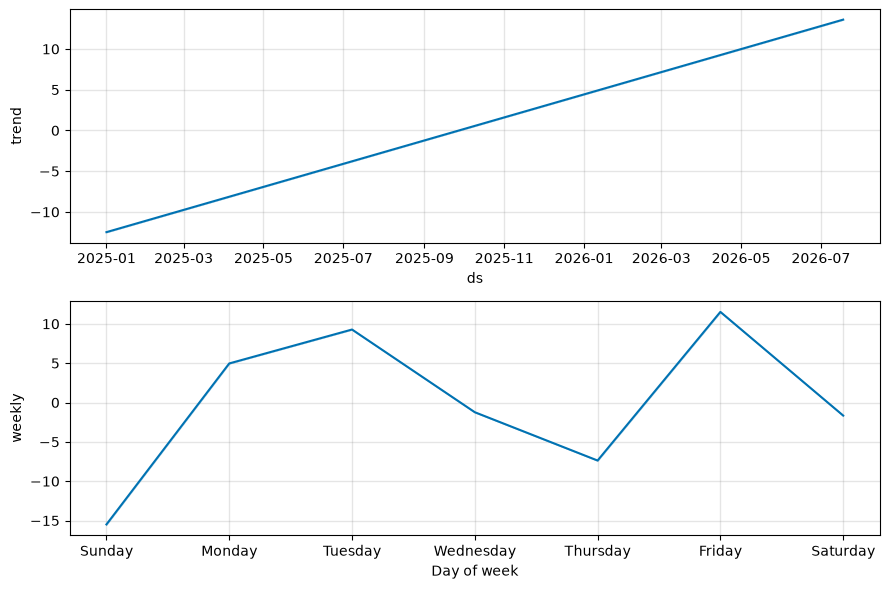

In [11]:
# Weekly seasonality decomposition
if prophet_model is not None:
    import matplotlib.pyplot as plt
    fig = prophet_model.plot_components(
        prophet_model.predict(prophet_model.make_future_dataframe(periods=30)))
    plt.tight_layout(); plt.show()

## Save to production artifact

Everything above trained interactively for exploration. This final cell calls the exact
same `src.models.delay.train()` function `src/train_pipeline.py` calls, saving to the same
`models/delay/` location — so running this notebook end-to-end (with whatever parameters
you changed above) is a complete, equivalent alternative to running the pipeline command,
not just a demo.


In [12]:
from src.models import delay as delay_model

ROOT = Path(dl.__file__).resolve().parents[2]
FOUNDATION_PATH = ROOT / "data" / "processed" / "foundation_arrivals_full.parquet"
SAVE_DIR = ROOT / "models" / "delay"

result = delay_model.train(FOUNDATION_PATH, SAVE_DIR, epochs=30)
print(f"HistGBM MAE: {result['hgbm_mae']:.2f} min | LSTM MAE: {result['lstm_mae']:.2f} min | "
      f"{result['prophet_count']} Prophet models saved")
print(f"-> Artifacts saved to {SAVE_DIR.resolve()}")


  Chargement de la fondation...
  Signal météo (rain_frac) : 54% des lignes couvertes (cache: C:\Users\deadx\OneDrive\Desktop\winicari\data\processed\day_weather.parquet)
  Division : train=101,036 lignes (jours<20260116)  test=28,198 lignes (jours>=20260116)
  Entraînement de HistGBM (global + par société si assez de données)...
    MAE test (global) : 3.12 min
    S.R.T.K: MAE=4.10 min (7718 lignes test, dédié)
    S.R.T.SELIANA: MAE=10.14 min (183 lignes test, repli global)
    S.T.S: MAE=2.91 min (1539 lignes test, dédié)
    SRT.ELGOUAFEL: MAE=5.71 min (4654 lignes test, repli global)
    TCV: MAE=1.46 min (14104 lignes test, dédié)
  Entraînement du LSTM (30 époques, patience=5)...
  époque   5/30  train=73.7321  val=76.9873
  époque  10/30  train=51.0807  val=56.6796
  époque  15/30  train=46.9137  val=52.3406
  époque  20/30  train=45.1034  val=51.5046
  époque  25/30  train=43.8504  val=48.9241
  époque  30/30  train=42.6494  val=51.4757
    MAE test : 3.33 min
  Ajustement de

14:23:47 - cmdstanpy - INFO - Chain [1] start processing
14:23:47 - cmdstanpy - INFO - Chain [1] done processing
14:23:47 - cmdstanpy - INFO - Chain [1] start processing
14:23:47 - cmdstanpy - INFO - Chain [1] done processing
14:23:47 - cmdstanpy - INFO - Chain [1] start processing
14:23:48 - cmdstanpy - INFO - Chain [1] done processing
14:23:48 - cmdstanpy - INFO - Chain [1] start processing
14:23:48 - cmdstanpy - INFO - Chain [1] done processing
14:23:48 - cmdstanpy - INFO - Chain [1] start processing
14:23:48 - cmdstanpy - INFO - Chain [1] done processing
14:23:48 - cmdstanpy - INFO - Chain [1] start processing
14:23:48 - cmdstanpy - INFO - Chain [1] done processing
14:23:48 - cmdstanpy - INFO - Chain [1] start processing
14:23:48 - cmdstanpy - INFO - Chain [1] done processing
14:23:48 - cmdstanpy - INFO - Chain [1] start processing
14:23:48 - cmdstanpy - INFO - Chain [1] done processing
14:23:48 - cmdstanpy - INFO - Chain [1] start processing
14:23:49 - cmdstanpy - INFO - Chain [1]

    63 modèles Prophet sauvegardés
  -> Artefacts de retard sauvegardés dans C:\Users\deadx\OneDrive\Desktop\winicari\models\delay
HistGBM MAE: 3.12 min | LSTM MAE: 3.33 min | 63 Prophet models saved
-> Artifacts saved to C:\Users\deadx\OneDrive\Desktop\winicari\models\delay
